<div style="text-align: justify; max-width: 90ch">

# Lecture 01c: Prompts as code, roles, and structured output

**Status: Mandatory reading.**

`lec_01b` chose the model. Now the other half of every call: the text you send. In a chat window a prompt is something you type once and lose;
in a system it is **code**: written as a function, versioned, tested, and its output parsed by a program, not read by a person.

**What this notebook covers**

- A prompt as a Python function with a version.
- The three **roles** (`system`, `user`, `assistant`) and why a model has no memory.
- **Few-shot** examples: showing instead of telling.
- **Structured output**: making the model return JSON that matches a schema, so pandas can take it from there.
- **Caching** the answers, so a re-run does not call the model again.
- Streaming, for the user who is waiting.

</div>

In [1]:
import json

import ollama
import pandas as pd

In [2]:
# --- Course configuration: edit TIER only; settings in .env (01d_env_hugging_face) ---
TIER = "cpu"  # 8-16 GB RAM, no GPU (default)
# TIER = "gpu"  # >= 8 GB VRAM: bigger, better answers (pull qwen3:8b first)

import os
from pathlib import Path

from dotenv import load_dotenv

REPO = Path.cwd().resolve().parents[1]  # this notebook runs from reading_material/
load_dotenv(REPO / ".env")  # your settings file: OLLAMA_HOST, HF_TOKEN, ...
TIER = os.environ.get("COURSE_TIER", TIER)  # tools/run_all.py can override
os.environ.setdefault(
    "HF_HUB_DISABLE_PROGRESS_BARS", "1"
)  # no download bars in saved outputs
CHAT_MODEL = {"cpu": "qwen3:1.7b", "gpu": "qwen3:8b"}[TIER]
EMBED_MODEL = "nomic-embed-text"
OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
MLFLOW_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://127.0.0.1:5010")
# To override .env in this notebook only, uncomment and edit (never a token):
# OLLAMA_HOST = "http://192.168.1.20:11434"
# MLFLOW_URI = "http://127.0.0.1:5011"
EXPERIMENT = "llm-course-01-basics"
DATA_DIR = REPO / "data"  # gitignored runtime state (indexes, caches)

from llm_course.checks import check_ollama

check_ollama(OLLAMA_HOST, [CHAT_MODEL])

Ollama OK at http://localhost:11434; models ready: qwen3:1.7b


<div style="text-align: justify; max-width: 90ch">

## 1. A prompt is a function

A prompt (`lec_01a`) is the whole text a model receives: instructions, examples, data, and the question. Once a program sends it, three problems appear:

- **Wording changes the answer.** The same question asked five slightly different ways gives five different answers, so the exact text matters as much as a hyperparameter.
- **Copies drift.** A prompt pasted into three notebooks becomes three different prompts after the first edit.
- **Results need a source.** When an answer is good or bad, someone asks which prompt produced it, and nobody remembers the wording.

The fix is the one you know from the Python course: put the prompt in a function with named inputs, and give it a version.

</div>

<div style="text-align: justify; max-width: 90ch">

Each part maps to something you already know:

| Prompt as code | What you already know |
| --- | --- |
| `build_prompt(question, style)` | a function: the fixed text is the body, what changes is a parameter |
| `PROMPT_VERSION = "v1"` | a parameter you would log with `mlflow.log_param`: which prompt made this result |
| the prompt in a file under git | any other code: reviewed, compared with a diff, restored |

</div>

<div style="text-align: justify; max-width: 90ch">

We also define `ask`, a small wrapper around `client.chat` (`lec_01a`) with the course defaults, so the rest of the notebook shows the prompts,
not the plumbing:

- `think=False`: thinking off (`lec_01b`).
- `temperature` 0 and `num_predict` 200: the most likely token every time, at most 200 tokens of answer (`lec_01a`).
- `system`: an optional system message (section 2).
- `**options` collects extra keyword arguments into a dict and puts them last, so they win: section 3 calls `ask(..., num_predict=10)`.

</div>

In [3]:
client = ollama.Client(host=OLLAMA_HOST)

PROMPT_VERSION = "v1"


def build_prompt(question, style="one sentence"):
    """Wrap a student's question with the instructions we want the model to follow."""
    return f"You are answering a question from a Python course. Reply in {style}.\n\nQuestion: {question}"


def ask(prompt, system=None, **options):
    """Send one prompt (plus an optional system message) and return the answer text."""
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})
    response = client.chat(
        model=CHAT_MODEL,
        messages=messages,
        think=False,
        options={"temperature": 0, "num_predict": 200, **options},
    )
    return response.message.content.strip()

In [4]:
question = "What does the axis argument mean in pandas drop()?"

print(ask(build_prompt(question)))
print("---")
print(ask(build_prompt(question, style="a bulleted list of at most three points")))

The `axis` argument in pandas' `drop()` method specifies whether to drop rows or columns.
---


- The `axis` argument in `pandas.drop()` specifies whether to drop rows or columns.  
- `axis=0` drops rows, and `axis=1` drops columns.  
- It allows you to remove specific rows or columns from a DataFrame.


<div style="text-align: justify; max-width: 90ch">

Two calls, one function, one variable changed, and more than the layout changed: the one-sentence answer says "rows or columns",
the list also says which is which (`axis=0` drops rows, `axis=1` columns). That is the first problem above, in two calls.
When a colleague asks "which prompt did you use?", the answer is `build_prompt`, version `v1`, and a diff.

</div>

<div style="text-align: justify; max-width: 90ch">

## 2. Roles: system, user, assistant

`lec_01a` sent a list with one message, from the `user`. A chat call can send several, and each message's **role** says who wrote it ([roles](https://huggingface.co/docs/transformers/en/chat_templating) in the Hugging Face docs):

| Role | Who writes it | Typical content |
| --- | --- | --- |
| `system` | you, once | who the model is, rules it must follow, the language to answer in |
| `user` | the person (or your code) | the question |
| `assistant` | the model | its previous answers |

The model does not see a list: Ollama lays the messages out as one text, each marked with its role, using the model's **chat template**,
a recipe of special markers for where each message starts and who wrote it (the optional `lec_01e` shows one).

</div>

<div style="text-align: justify; max-width: 90ch">

Why a separate `system` message, when the rules could sit at the top of every question?

- **Written once, by you.** The rules live in your code; the question changes with every user, the rules do not.
- **Read as directives.** Chat models are fine-tuned on conversations laid out with these roles, and treat the system message as directives on how to act.
- **First in every call.** In a conversation it stays at the top of the history (below), so every call carries the rules,
  the tenth one too.

The **system prompt**, the text of the `system` message, is where product rules live: tone, language, refusals, format. Same question, two system prompts.

</div>

In [5]:
tutor = (
    "You are a teaching assistant for a Python course. Answer in at most two sentences."
)
tutor_greek = tutor + " Always answer in Greek."

print(ask(question, system=tutor))
print("---")
print(ask(question, system=tutor_greek))

The `axis` argument in `pandas.drop()` specifies whether to drop the specified labels from a row (axis=0) or column (axis=1).
---


Η αξία του παραμέτρου axis στο pandas drop() είναι η διαφορά μεταξύ των περιοχών που πρέπει να αφαιρεθούν. Αν είναι 0, αφαιρείται η στήλη, αν είναι 1, αφαιρείται η γραμμή.


<div style="text-align: justify; max-width: 90ch">

The rule worked: the second answer is in Greek. The content did not: it says 0 removes a column and 1 a row, the reverse of the English answer and of pandas, where `axis=0` drops rows.
It also slips on grammar ("του παραμέτρου" for "της παραμέτρου"). Fluent-looking text, wrong meaning: the *languages* requirement from `lec_01b` failing quietly, because small models are weaker in less common languages.
A system prompt controls the form of an answer more reliably than its truth, so read the Greek answer against the English one before trusting it.

Now the part that surprises everyone: **the model has no memory**. Every call starts from nothing; a conversation exists only because your code sends the previous messages again, with the `assistant` role.

</div>

In [6]:
# WRONG: the second question alone; the model has never seen the first exchange
follow_up = "Can you show a one-line example of it?"
print(ask(follow_up, system=tutor))

Sure! Here's a one-line example: `print("Hello, world!")`


In [7]:
# RIGHT: resend the history, then the follow-up
history = [
    {"role": "system", "content": tutor},
    {"role": "user", "content": question},
    {"role": "assistant", "content": ask(question, system=tutor)},
    {"role": "user", "content": follow_up},
]
response = client.chat(
    model=CHAT_MODEL,
    messages=history,
    think=False,
    options={"temperature": 0, "num_predict": 200},
)
print(response.message.content.strip())

For example: `df.drop(axis=1, labels=['column1', 'column2'])` removes columns `column1` and `column2` from the DataFrame.


<div style="text-align: justify; max-width: 90ch">

Read the two answers. Alone, the follow-up got `print("Hello, world!")`: the model did not know what "it" was, and invented something rather than ask.
With the history, the same words got `df.drop(axis=1, labels=['column1', 'column2'])`. The `assistant` message was regenerated here with `ask`;
a real application stores the answer it already showed.

Chat applications do exactly this behind the scenes, which is why long conversations get slower and eventually hit the context window from `lec_01a`:
every turn resends every earlier token, and a hosted model bills them again each time.

</div>

<div style="text-align: justify; max-width: 90ch">

## 3. Few-shot examples

Describing a format in words works less well than showing it. A **shot** is one worked example, a question with its answer, placed inside the prompt:

| Name | The prompt contains |
| --- | --- |
| **zero-shot** | the instruction only |
| **few-shot** | the instruction plus a few worked examples |

It works because a model predicts text from the text before it (`lec_01a`): after three `Question:` / `Category:` pairs and a fourth `Question:`,
the likeliest reply follows the pattern and names a category. The price is tokens: the examples travel with every call. Here the task is to tag a student's forum question with one category.

</div>

In [8]:
FEW_SHOT = """Tag the question with exactly one category: pandas, plots, sklearn, python-basics, or other.

Question: How do I read an Excel file into a DataFrame?
Category: pandas

Question: Why does my for loop print the last value only?
Category: python-basics

Question: Which metric should I use for an imbalanced classification?
Category: sklearn

Question: {question}
Category:"""

print(
    ask(
        FEW_SHOT.format(question="How do I change the colours in a seaborn heatmap?"),
        num_predict=10,
    )
)

Category: pandas


<div style="text-align: justify; max-width: 90ch">

The model answered `Category: pandas`, and the tag is wrong: a seaborn heatmap is a chart, so the right one is `plots`. Look at what the prompt gave the model:

- **Examples for three categories only.** `pandas`, `python-basics` and `sklearn` have one each; `plots` and `other` have none.
- **Names without meanings.** Nothing says that seaborn belongs to `plots`.

Section 4 adds a one-line definition per category, and with it section 5 tags both chart questions as `plots`. The model also wrote the `Category:` label again, although the prompt already ended with it:
free text does not keep to a format, which is the next problem.

</div>

<div style="text-align: justify; max-width: 90ch">

## 4. Structured output

The answer above is text. To count categories, filter them, or plot them, a program has to **parse** it, turn the text into values it can use,
and text parsing breaks the day the model adds a word.

</div>

In [9]:
# WRONG: parse free text and hope the format never changes
raw = ask(
    FEW_SHOT.format(question="My notebook kernel keeps dying when I load a big CSV"),
    num_predict=20,
)
print(repr(raw))
category = (
    raw.split(":")[-1].strip().strip(".").lower()
)  # breaks on "Category: **pandas** (probably)" or a two-line answer
print(category)

'Category: pandas'
pandas


<div style="text-align: justify; max-width: 90ch">

It worked this time. It works until the model answers `Category: **pandas** (probably)`, or adds a second line, and then a `KeyError` appears three cells later in a `groupby`.

The fix is **structured output**: the model answers in a fixed, machine-readable format instead of prose. The usual format is [JSON](https://www.json.org/json-en.html), the text format web services exchange;
MLflow's model serving used it in lecture 13 of the Python course. `json.loads`, from Python's [`json`](https://docs.python.org/3/library/json.html) module,
turns JSON text into Python values:

| JSON | Python |
| --- | --- |
| object `{"key": value}` | `dict` |
| array `[1, 2]` | `list` |
| string, number | `str`, `int` or `float` |
| `true`, `false`, `null` | `True`, `False`, `None` |

</div>

<div style="text-align: justify; max-width: 90ch">

Structured output tells the model the *shape* of the answer, not the wording. A [**JSON schema**](https://json-schema.org/learn/getting-started-step-by-step) is a dictionary that describes a JSON object;
`TAG_SCHEMA` below uses five of its keywords:

| Keyword | Means |
| --- | --- |
| `type` | what a value is: `object` (a dict), `string`, `boolean` |
| `properties` | the keys the object may have, each with its own `type` |
| `required` | the keys it must have |
| `enum` | the only allowed values, spelled exactly ([reference](https://json-schema.org/understanding-json-schema/reference/enum)) |
| `description` | a note on what the value should be; [not a rule](https://json-schema.org/understanding-json-schema/reference/annotations) |

</div>

<div style="text-align: justify; max-width: 90ch">

Ollama takes the schema as `format=` ([structured outputs](https://docs.ollama.com/capabilities/structured-outputs)). At each step the model gives every token a probability (`lec_01a`);
with a schema, Ollama allows only the tokens that keep the answer valid against it, so the model picks among those. This is called **constrained decoding**:
the output is valid JSON of that shape, with no parsing code, as long as `num_predict` leaves room to finish it. A cut-off answer is cut-off JSON, and `json.loads` fails.

The prompt still matters. `CATEGORIES` gives each category a one-line definition, and there are no examples this time: a zero-shot prompt, because the schema now enforces the format.

</div>

In [10]:
CATEGORIES = """Categories:
- pandas: DataFrames, reading files, merging, grouping, missing values
- plots: charts and figures (matplotlib, seaborn, plotly)
- sklearn: models, metrics, train/test split, GridSearchCV, pipelines
- python-basics: syntax, loops, functions, errors, installing packages, the command line
- other: anything else (deployment, tools, accounts)"""

TAG_SCHEMA = {
    "type": "object",
    "properties": {
        "category": {
            "type": "string",
            "enum": ["pandas", "plots", "sklearn", "python-basics", "other"],
        },
        "needs_code": {"type": "boolean"},
        "summary": {
            "type": "string",
            "description": "the question in at most ten words",
        },
    },
    "required": ["category", "needs_code", "summary"],
}


def tag_question(question):
    """Return a dict with category, needs_code, summary for one forum question."""
    response = client.chat(
        model=CHAT_MODEL,
        messages=[
            {
                "role": "user",
                "content": f"Tag this Python-course forum question with one category.\n\n{CATEGORIES}\n\nQuestion: {question}",
            }
        ],
        format=TAG_SCHEMA,  # RIGHT: the model must return JSON matching the schema
        think=False,
        options={"temperature": 0, "num_predict": 100},
    )
    return json.loads(response.message.content)


tag_question("My while loop never stops, what did I do wrong?")

{'category': 'python-basics',
 'needs_code': False,
 'summary': 'Identifies the issue with an infinite while loop in Python.'}

<div style="text-align: justify; max-width: 90ch">

`json.loads` turned the text into a dict; JSON's `false` became Python's `False`. The `enum` guarantees the category is one of your five, spelled your way.
The category *definitions* in the prompt do the other half of the work: without them a small model tags most questions as `python-basics`.

Now the `summary`. The schema's `description` asks for at most ten words, and this run gave exactly ten. Run it again and you may get thirty:
in one example run with this same prompt, seven of thirteen questions got summaries longer than ten words, one of them 51.
The next cell shows why the rule is luck.

</div>

In [11]:
# The schema is not part of the prompt: the same message costs the same tokens with or without it
check = [
    {
        "role": "user",
        "content": f"Tag this Python-course forum question with one category.\n\n{CATEGORIES}\n\nQuestion: My while loop never stops, what did I do wrong?",
    }
]
for label, schema in [("with the schema", TAG_SCHEMA), ("without it", None)]:
    response = client.chat(
        model=CHAT_MODEL,
        messages=check,
        format=schema,
        think=False,
        options={"temperature": 0, "num_predict": 1},
    )
    print(f"prompt tokens {label}: {response.prompt_eval_count}")

prompt tokens with the schema: 121
prompt tokens without it: 121


<div style="text-align: justify; max-width: 90ch">

The same count, 121 tokens, with the schema or without it: `prompt_eval_count` (`lec_01a`) is what the model read, and the schema added nothing to it.
Ollama uses the schema only to restrict which tokens may come next (constrained decoding, above). So the `enum` works, because it limits the tokens, and the `description` does nothing, because the model never reads it.

A rule the model must follow belongs in the prompt. Ollama's [docs](https://docs.ollama.com/capabilities/structured-outputs) also suggest repeating the schema there.

</div>

In [12]:
# RIGHT: a rule the model must follow goes in the prompt; the schema only fixes the shape
TAG_PROMPT_VERSION = "v2"  # v1 had the ten-word rule only in the schema's description


def tag_question(question):
    """Return a dict with category, needs_code, summary for one forum question."""
    response = client.chat(
        model=CHAT_MODEL,
        messages=[
            {
                "role": "user",
                "content": (
                    "Tag this Python-course forum question with one category, "
                    "and summarise it in at most ten words.\n\n"
                    f"{CATEGORIES}\n\nQuestion: {question}"
                ),
            }
        ],
        format=TAG_SCHEMA,
        think=False,
        options={"temperature": 0, "num_predict": 100},
    )
    return json.loads(response.message.content)


tag_question("My while loop never stops, what did I do wrong?")

{'category': 'python-basics',
 'needs_code': True,
 'summary': 'While loop not terminating due to missing condition'}

<div style="text-align: justify; max-width: 90ch">

With the rule in the prompt, the summary has eight words: "While loop not terminating due to missing condition". Section 5 uses this version, and all twelve of its summaries keep to ten words.

The edit raised `TAG_PROMPT_VERSION` to `"v2"`, because a prompt change can change every answer, not only the one you aimed at:
in one example run this edit also moved two questions from wrong categories to `sklearn`. Section 5 puts that version into the name of its cache.

</div>

<div style="text-align: justify; max-width: 90ch">

## 5. From answers to a DataFrame

Twelve real-looking forum questions, one call each, straight into pandas. `{"question": q, **tag_question(q)}` builds one dict per question (`**` unpacks the tagged dict into the new one),
and `pd.DataFrame` turns a list of dicts into a table, one row per dict. The schema is what makes this safe: every answer has the same three keys, so every row has the same columns.

</div>

<div style="text-align: justify; max-width: 90ch">

The results are **cached**: the first run saves them to a CSV in `data/`, and every later run reads the file instead of calling the model.
Why cache model answers:

- **Time.** Every call runs the model; reading the file takes milliseconds.
- **Cost.** A hosted model bills every call by the token (`lec_01a`), and every re-run pays again.
- **Reproducibility.** Temperature 0 is only nearly deterministic (`lec_01a`), and models get updated; in one example run, calling again changed one of the twelve categories.

</div>

<div style="text-align: justify; max-width: 90ch">

The catch: an answer is valid only for the model and the prompt that produced it. Both go into the file name, `lec_01c_tags_qwen3-1.7b_v2.csv`,
so switching `TIER` or raising `TAG_PROMPT_VERSION` starts a new file. Edit the prompt without raising the version, and you read old answers.

⏱ **Skip if running long.** In one example run on a laptop CPU the twelve calls took about 30 seconds; the cached CSV in `data/` (if present) is used instead.

</div>

In [13]:
forum_questions = [
    "How do I merge two DataFrames on a customer id?",
    "Why is my bar chart showing the categories in the wrong order?",
    "What is the difference between fit and fit_transform?",
    "My while loop never stops, what did I do wrong?",
    "How can I drop rows with missing values only in one column?",
    "Which plot shows the relationship between two numeric columns?",
    "GridSearchCV takes forever, how do I make it faster?",
    "What does if __name__ == '__main__' do?",
    "Can I deploy my Gradio app without a credit card?",
    "How do I group by month and sum the sales?",
    "Is accuracy a good metric when one class is rare?",
    "The pip install command says permission denied",
]

# One file per model and prompt version, so changing either starts a new cache
# (":" is replaced because Windows does not allow it in file names).
cache_path = (
    DATA_DIR / f"lec_01c_tags_{CHAT_MODEL.replace(':', '-')}_{TAG_PROMPT_VERSION}.csv"
)
DATA_DIR.mkdir(exist_ok=True)

if cache_path.exists():
    tagged = pd.read_csv(cache_path)
else:
    tagged = pd.DataFrame([{"question": q, **tag_question(q)} for q in forum_questions])
    tagged.to_csv(cache_path, index=False)

tagged

,question,category,needs_code,summary
0,How do I merge two DataFrames on a customer id?,pandas,True,Merge two DataFrames on customer ID
1,Why is my bar chart showing the categories in ...,plots,True,Bar chart categories not in correct order
2,What is the difference between fit and fit_tra...,sklearn,True,Explain fit vs fit_transform in sklearn
3,"My while loop never stops, what did I do wrong?",python-basics,True,While loop not terminating due to missing cond...
4,How can I drop rows with missing values only i...,pandas,True,Drop rows with missing values in a specific co...
5,Which plot shows the relationship between two ...,plots,True,Shows relationship between two numeric columns
6,"GridSearchCV takes forever, how do I make it f...",sklearn,True,Speed up GridSearchCV with optimizations
7,What does if __name__ == '__main__' do?,python-basics,True,Explains the purpose of the __main__ check in ...
8,Can I deploy my Gradio app without a credit card?,other,False,Can I deploy my Gradio app without a credit card?
9,How do I group by month and sum the sales?,pandas,True,Group by month and sum sales using pandas.


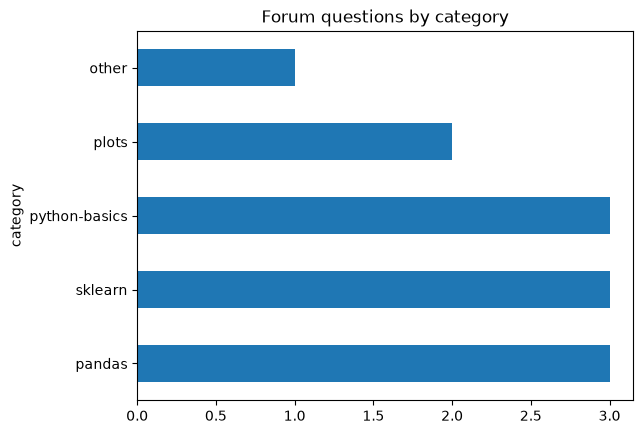

In [14]:
tagged["category"].value_counts().plot(
    kind="barh", title="Forum questions by category"
);

<div style="text-align: justify; max-width: 90ch">

### ⏸ Pause point

Look at the rows, not the plot: would you have tagged each one the same way? Every category here is defensible, so look at `needs_code`.
Does row 5, "Which plot shows the relationship between two numeric columns?", need code, or one word: a scatter plot? Where you disagree with the model is exactly where lecture 3 starts:
measuring how often it is right.

</div>

<div style="text-align: justify; max-width: 90ch">

## 6. Streaming

Everything so far waited for the full answer. A model writes one token at a time (`lec_01a`), so on a laptop CPU a 120-token answer keeps a person looking at an empty screen for several seconds.
**Latency**, how long the user waits, is one of the requirements of `lec_01b`, and streaming changes which wait counts:

| Mode | The user sees | The wait that counts |
| --- | --- | --- |
| without streaming | nothing, then the whole answer | time to the last token |
| `stream=True` | the first words, then the rest as they are generated | **time to first token** |

The total time is the same; the answer only starts sooner.

</div>

<div style="text-align: justify; max-width: 90ch">

`stream=True` makes `client.chat` return the answer as a sequence of **chunks** instead of one response ([streaming](https://docs.ollama.com/capabilities/streaming)).
A `for` loop receives each chunk as it is generated, and `chunk.message.content` holds its new text. In `print`, `end=""` keeps the pieces on one line,
and `flush=True` shows each one at once instead of holding it in a buffer.

</div>

In [15]:
stream = client.chat(
    model=CHAT_MODEL,
    messages=[
        {
            "role": "user",
            "content": build_prompt(
                "Why do we split data before scaling it?", style="three sentences"
            ),
        }
    ],
    think=False,
    stream=True,
    options={"temperature": 0, "num_predict": 120},
)
for chunk in stream:
    print(chunk.message.content, end="", flush=True)
print()

We

 split

 data

 before

 scaling

...

 of

 the

 scaling

 method

.

<div style="text-align: justify; max-width: 90ch">

Each chunk above is one token: `Split` and `ting` arrived separately, the way the tokenizer cut the word (`lec_01a`). Read what arrived, too.
None of the three sentences gives the real reason, data leakage (the first question of `lec_01a`): a scaler fitted on all rows has seen the test set's mean and spread.
The first sentence is muddled, the second is about scaling itself, and the third only gestures at "proper evaluation". Streaming changes when words appear, not whether they are right.

</div>

<div style="text-align: justify; max-width: 90ch">

When to stream:

- **A person is watching**, as in a chat window: stream.
- **A program reads the answer**, as in section 5's tagging: no gain, nothing happens until the whole answer is there.
- **The answer is JSON**: `json.loads` needs the complete text, so stream only to show progress.

To keep a streamed answer, for the history of section 2, join the chunks yourself.

</div>

<div style="text-align: justify; max-width: 90ch">

## Recap

- A **prompt** is code: a function with named inputs and a version.
- Messages have **roles**; the system prompt carries the product rules; the model remembers nothing, your code resends the history.
- **Few-shot** examples show the format; definitions say what each category means.
- **Structured output** (`format=` a JSON schema) fixes the shape of an answer, its keys, types and `enum` values, not its content:
  read the rows.
- The model never reads the schema: a rule such as "at most ten words" goes in the prompt.
- **Cache** model answers for time, cost and reproducibility, under a name that carries the model and the prompt version.
- `stream=True` shows the first words sooner; the total time is the same.

**Next: `lec_01d`**, the same ideas with LangChain, a library that names these parts (prompt template, chain, parser) and chains them.

</div>